In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

#### Implicit FDM scheme

In [2]:
#Defining variables to use later
x_min = -1
x_max = 1
x_steps = 120
t_max = 312 # Hours
t_max0 = t_max
t_max = t_max * 3600 # Convert to seconds
t_steps = 10

R = 8.314e-3      # kJ/(mol*K)
T = 1273          # K (1000 °C)

D0_Cu, Q_Cu = 31, 200.3     # mm^2/s, kJ/mol
D0_Ni, Q_Ni = 190, 279.7    # mm^2/s, kJ/mol

D0_Cu = D0_Cu * np.exp(-Q_Cu / (R * T))   # Cu*  in Cu
D0_Ni = D0_Ni * np.exp(-Q_Ni / (R * T)) # Ni*  in Ni
D = D0_Cu
# D = 10**-5



In [3]:
def setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D):
    x = np.linspace(x_min, x_max, x_steps)
    C_matrix = np.zeros((t_steps, x_steps))
    C_matrix[0, :] = np.heaviside(x, 0.5)   # Using heaviside function to set the first row to 1 for x >= 0 and 0 for x < 0
    dx = (x_max - x_min) / (x_steps - 1)
    dt = t_max / (t_steps - 1)
    r = np.full((x_steps,), D * dt / dx**2)  # r is a vector of length x_steps with the same value D*dt/dx^2
    return C_matrix, dx, dt, r, x

C_matrix, dx, dt, r, x = setup()


In the cell above, a grid of 0s is defined, with the initial condition, C = 1 for positive x and 0 for negative x, is put into the grid. Also, dx, dt and r is defined. The r is defined to make calculations easier, and is a constant for a set time and space step, as well as a constant diffusion coefficiant.

Solving for the next time step for any given space point gives the following:

$$-r\,C_{i-1}^{n+1} + (1+2r)\,C_i^{n+1} - r\,C_{i+1}^{n+1} = C_i^n$$





The cell below solves one step of the implicit system, using a linalg system of this form if Direcht is false, i.e. using Neumann:


$$
\begin{pmatrix}
1+2r & -2r &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & -2r & 1+2r
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

Here, the 2r points are because of the mirroring of these end points. 

And similarly for Direcht true, this is implemented to hold the end points constant:
$$
\begin{pmatrix}
1 & 0 &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & 0 & 1
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

The first and last rows are replaced by identity rows, which enforce $C_0^{n+1} = C_0^{n}$ and $C_N^{n+1} = C_N^{n}$. The boundary values are therefore carried unchanged from the initial condition, here 0 and 1.

Eliminating the boundary nodes under the Dirichlet condition leaves a
symmetric, positive definite tridiagonal system for the interior unknowns,
which permits a Cholesky factorization instead of LU.

In [4]:
def implicit_system_one_step(C_matrix, r, step, s=None, Dirichlet=False, Picard=False, dt=None, dx=None, tol=1e-8, max_iter=30):
    C0 = C_matrix[step, :]
    if s is None:
        s = np.zeros_like(C0)
    if Picard and (dt is None or dx is None):
        raise ValueError("Picard=True requires dt and dx to be passed in.")

    def build_and_solve(r, s):
        A = np.zeros((len(C0), len(C0)))
        for i in range(0, len(C0)):
            A[i, i] = 2*r[i] + 1
            if i != 0:
                A[i, i-1] = -r[i] + s[i]
            if i != len(C0)-1:
                A[i, i+1] = -r[i] - s[i]
        if not Dirichlet:
            A[0, 1] = -2*r[0]
            A[-1, -2] = -2*r[-1]
        elif Dirichlet:
            A[0, 0] = 1
            A[0, 1] = 0
            A[-1, -1] = 1
            A[-1, -2] = 0
        np.set_printoptions(precision=3, suppress=True, linewidth=120)
        return np.linalg.solve(A, C0)

    if not Picard:
        return build_and_solve(r, s)

    C_guess = C0.copy()
    for k in range(max_iter):
        D_tilda_vector = D_tilda_spline_vector(C_guess)
        r_k = r_vector(D_tilda_vector, dt, dx)
        s_k = s_vector(D_tilda_vector, dt, dx)
        C_new = build_and_solve(r_k, s_k)
        if np.max(np.abs(C_new - C_guess)) < tol:
            return C_new
        C_guess = C_new
    return C_guess

In [5]:
def main():
    for step in range(0, t_steps-1):
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, Picard=False, dt=dt, dx=dx)
    return C_matrix

C_matrix = main()

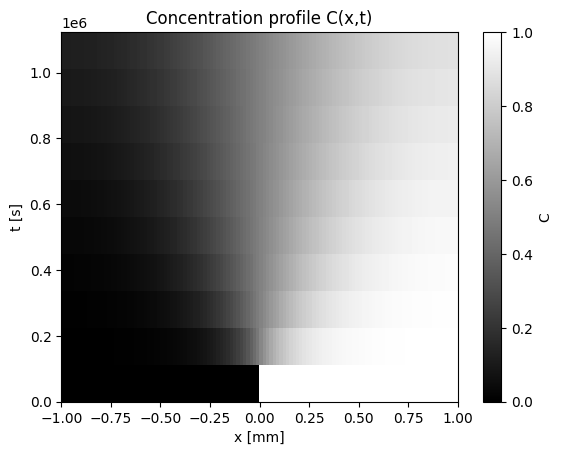

In [6]:

plt.imshow(C_matrix, aspect='auto', origin='lower', cmap='gray',
           extent=[x_min, x_max, 0, t_max])
plt.colorbar(label='C')
plt.xlabel('x [mm]')
plt.ylabel('t [s]')
plt.title('Concentration profile C(x,t)')
plt.show()

In [7]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

def animate_profile(C_matrix, x_min, x_max, dt, title='Concentration bar',
                    total_duration=15, n_frames=100):
    plt.close('all')
    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    frames = np.linspace(0, t_steps - 1, min(n_frames, t_steps), dtype=int)
    interval_ms = int(total_duration * 1000 / len(frames))

    fig = plt.figure(figsize=(9, 5))
    ax_bar  = fig.add_axes([0.12, 0.78, 0.80, 0.14])
    ax_line = fig.add_axes([0.12, 0.14, 0.80, 0.52])

    img = ax_bar.imshow(C_matrix[[0]], cmap='gray', aspect='auto',
                        vmin=0, vmax=1, extent=[x_min, x_max, 0, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])
    ttl = ax_bar.set_title(f'{title}, t = 0.00 hours')

    line, = ax_line.plot(x, C_matrix[0], lw=2)
    ax_line.set_xlim(x_min, x_max)
    ax_line.set_ylim(-0.02, 1.02)
    ax_line.set_xlabel('$x$ [mm]')
    ax_line.set_ylabel('$C$')
    ax_line.grid(alpha=0.3, lw=0.5)

    def update(i):
        n = frames[i]
        img.set_data(C_matrix[[n]])
        line.set_ydata(C_matrix[n])
        ttl.set_text(f'{title}, t = {n*dt/3600:.2f} hours')
        return img, line, ttl

    anim = FuncAnimation(fig, update, frames=len(frames),
                         interval=interval_ms, blit=False)
    plt.close(fig)                 # hindrer at det siste bildet vises i tillegg
    display(HTML(anim.to_jshtml()))

In [8]:
%matplotlib widget
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main()
animate_profile(C_matrix, x_min, x_max, dt,
                title='Self-diffusion, constant D');

In [9]:
def plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2, title = ""):
    plt.close('all')          # lukker gamle widget-figurer

    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    steps = np.linspace(0, t_steps - 1, n_curves, dtype=int)
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_curves))

    plt.figure(figsize=(7, 4.5))
    for c, n in zip(colors, steps):
        plt.plot(x, C_matrix[n], color=c, lw=1.8, label=f'{n*dt/3600:.1f} h')
    plt.xlabel('$x$ [mm]')
    plt.ylabel('$C$')
    plt.xlim(x_min, x_max)
    plt.ylim(-0.02, 1.02)
    plt.grid(alpha=0.3, lw=0.5)
    plt.legend(frameon=False, title='$t$')
    plt.title(title)
    plt.tight_layout()
    plt.show()


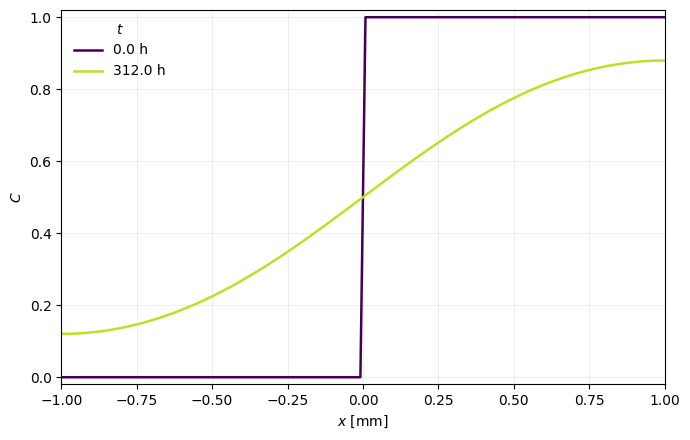

In [10]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main()

plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

## Part 2 (ii)

Here, we need the r as a function of local composition

$$ \frac{\partial C}{\partial t} = \tilde{D} \frac{\partial ^2 C}{\partial x^2} + \frac{\partial C}{\partial x} \frac{\partial \tilde{D}}{\partial x} $$

The first part corresponds to the same as before. The second part can be implemented in two separate schemes multiplied together. 

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = \tilde D_j^n\,\frac{C_{j+1}^{n+1}-2C_j^{n+1}+C_{j-1}^{n+1}}{(\Delta x)^2} + \left(\frac{\tilde D_{j+1}^n-\tilde D_{j-1}^n}{2\Delta x}\right)\left(\frac{C_{j+1}^{n+1}-C_{j-1}^{n+1}}{2\Delta x}\right)$$

Solved:
$$-\left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} - \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j-1}^{n+1} + \left(1+\frac{2\tilde D_j^n\,\Delta t}{(\Delta x)^2}\right)C_j^{n+1} - \left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} + \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j+1}^{n+1} = C_j^n$$

Defining variables to simplify the expression

$$r_j = \frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2}$$

$$s_j = \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}$$

Above, $\tilde D$ is evaluated at the old time level $n$, which makes the scheme semi-implicit. A fully implicit version would use $\tilde D_j^{n+1}=\tilde D(C_j^{n+1})$ instead, but since that depends on the unknown $C^{n+1}$, the system becomes non-linear. This is solved with a **Picard (fixed-point) iteration**: guess $C^{n+1,(0)}=C^n$, compute $r_j,s_j$ from that guess, solve the resulting linear system for a new iterate $C^{n+1,(k+1)}$, and repeat until the guess stops changing, i.e. until

$$
\left\|C^{n+1,(k+1)}-C^{n+1,(k)}\right\|_\infty < \mathrm{tol}
$$

At iteration $k$, evaluate $r_j^{(k)}$ and $s_j^{(k)}$ using $\mathbf C^{n+1,(k)}$, so that the matrix is $A^{(k)}=A(\mathbf C^{n+1,(k)})$. Then solve

$$
A(\mathbf C^{n+1,(k)})\mathbf C^{n+1,(k+1)}=\mathbf C^n.
$$

Thus,

$$
\mathbf C^{n+1,(k)}
\rightarrow
A(\mathbf C^{n+1,(k)})
\rightarrow
\mathbf C^{n+1,(k+1)}.
$$

Defining $G(\mathbf C^{n+1})$ as the solution $\mathbf X$ of

$$
A(\mathbf C^{n+1})\mathbf X=\mathbf C^n,
$$

the Picard iteration is

$$
\boxed{
\mathbf C^{n+1,(k+1)}
=
G\left(\mathbf C^{n+1,(k)}\right).
}
$$

If $G$ is a contraction, i.e. there exists $q<1$ such that

$$
\left\|
G(\mathbf C_1^{n+1})-G(\mathbf C_2^{n+1})
\right\|
\leq
q
\left\|
\mathbf C_1^{n+1}-\mathbf C_2^{n+1}
\right\|,
$$

then, by the Banach fixed-point theorem, the Picard iteration converges to the unique fixed point $\mathbf C^{n+1}$ satisfying

$$
\mathbf C^{n+1}=G(\mathbf C^{n+1}).
$$



In [11]:
# Importing the dataset from the csv file and sorting them


values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',')
composition = values[0].values
lg_D_tilda  = values[1].values


# Interpolating between the values


lg_D_tilda_spline = make_interp_spline(composition, lg_D_tilda, k=3)

In [12]:
# Taking in one step of concentrations and returning the effective diffusion coefficient D_tilda for each point in space.
def D_tilda(lg_D, C1_vector):
    return D1 * (1 - C1_vector) + D2 * C1_vector   # vektorisert

def D_tilda2(C1_vector):
    return D * (1 - C1_vector) + D * C1_vector   # vektorisert

# Defining the r for each D

def D_tilda_spline_vector(C1_vector):
    C1_vector = np.clip(C1_vector, composition.min(), composition.max())   # splinen skal aldri ekstrapolere
    lg_D_tilda_vector = lg_D_tilda_spline(C1_vector)
    return 10**lg_D_tilda_vector * 10**6

def r_vector(D_tilda_vector, dt, dx):
    return D_tilda_vector * dt / dx**2   # vektorisert, ingen loop nødvendig

# Defining the s for each D

def s_vector(D_tilda_vector, dt, dx):
    s = np.zeros(len(D_tilda_vector))
    s[1:-1] = (D_tilda_vector[2:] - D_tilda_vector[:-2]) * dt / (4 * dx**2)
    return s







With the new quantities defined, the same implicit scheme can be used

In [13]:
def main2():
    for step in range(0, t_steps-1):
        D_tilda_vector = D_tilda_spline_vector(C_matrix[step])
        r = r_vector(D_tilda_vector, dt, dx)
        s = s_vector(D_tilda_vector, dt, dx)
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, s, Picard=True, dt=dt, dx=dx)

    return C_matrix




In [14]:
%matplotlib widget
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
animate_profile(C_matrix, x_min, x_max, dt,
                title='Interdiffusion, concentration-dependent D');

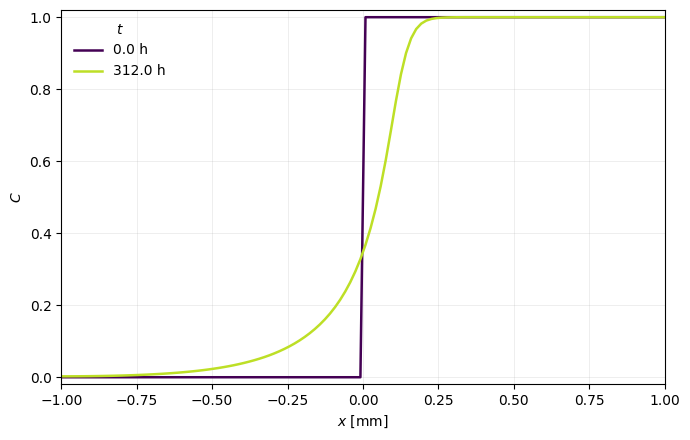

In [15]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

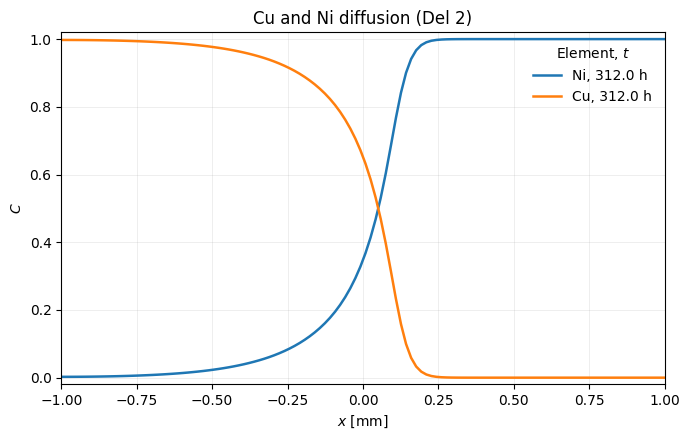

In [16]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()

plt.figure(figsize=(7, 4.5))
plt.plot(x, C_matrix[-1], color='#1f77b4', lw=1.8, label=f'Ni, {(t_steps-1)*dt/3600:.1f} h')
plt.plot(x, 1 - C_matrix[-1], color='#ff7f0e', lw=1.8, label=f'Cu, {(t_steps-1)*dt/3600:.1f} h')
plt.xlabel('$x$ [mm]')
plt.ylabel('$C$')
plt.xlim(x_min, x_max)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3, lw=0.5)
plt.legend(frameon=False, title='Element, $t$')
plt.title('Cu and Ni diffusion (Del 2)')
plt.tight_layout()
plt.show()

In [17]:
print("C spenn:", C_matrix.min(), C_matrix.max())
print("masse start:", C_matrix[0].sum(), " slutt:", C_matrix[-1].sum())

C spenn: 0.0 1.0
masse start: 60.0  slutt: 60.04806300149983


In [18]:
def mse_between_tsteps(configs_del1, configs_del2, x_steps=x_steps, x_min=x_min, x_max=x_max, D=D):
    """
    configs_del1, configs_del2: lister av (t_max, t_steps)-par som testes for hhv Del 1 og Del 2.
    Returnerer én tabell med MSE mellom sluttprofilene for påfølgende konfigurasjoner i hver liste.
    """
    def run(configs, del2):
        final_profiles = []
        for t_max_i, ts in configs:
            Cm, dx_, dt_, r_, x_ = setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max_i, t_steps=ts, D=D)
            for step in range(ts - 1):
                if del2:
                    D_tilda_vector = D_tilda_spline_vector(Cm[step])
                    r_step = r_vector(D_tilda_vector, dt_, dx_)
                    s_step = s_vector(D_tilda_vector, dt_, dx_)
                    Cm[step+1, :] = implicit_system_one_step(Cm, r_step, step, s_step)
                else:
                    Cm[step+1, :] = implicit_system_one_step(Cm, r_, step)
            final_profiles.append(Cm[-1, :])
        return [np.mean((final_profiles[i+1] - final_profiles[i])**2) for i in range(len(final_profiles) - 1)]

    mse_del1 = run(configs_del1, del2=False)
    mse_del2 = run(configs_del2, del2=True)

    rows = []
    for i, mse in enumerate(mse_del1):
        rows.append({'del': 1,
                      't_max_from': configs_del1[i][0], 't_steps_from': configs_del1[i][1],
                      't_max_to': configs_del1[i+1][0], 't_steps_to': configs_del1[i+1][1],
                      'mse': mse})
    for i, mse in enumerate(mse_del2):
        rows.append({'del': 2,
                      't_max_from': configs_del2[i][0], 't_steps_from': configs_del2[i][1],
                      't_max_to': configs_del2[i+1][0], 't_steps_to': configs_del2[i+1][1],
                      'mse': mse})

    return pd.DataFrame(rows)


mse_between_tsteps([(t_max, 20), (t_max, 1000)], [(t_max, 20), (t_max, 1000)])

,del,t_max_from,t_steps_from,t_max_to,t_steps_to,mse
0,1,1123200,20,1123200,1000,0.000004
1,2,1123200,20,1123200,1000,5.476257


In [20]:
def run_variant(picard, dirichlet, x_steps=x_steps, x_min=x_min, x_max=x_max, t_max=t_max, t_steps=t_steps, D=D):
    Cm, dx_, dt_, r_, x_ = setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D)
    for step in range(t_steps - 1):
        D_tilda_vector = D_tilda_spline_vector(Cm[step])
        r = r_vector(D_tilda_vector, dt_, dx_)
        s = s_vector(D_tilda_vector, dt_, dx_)
        Cm[step+1, :] = implicit_system_one_step(Cm, r, step, s, Dirichlet=dirichlet, Picard=picard, dt=dt_, dx=dx_)
    return Cm[-1, :], x_, t_steps


baseline,      x_, t_steps_baseline  = run_variant(picard=False, dirichlet=False)
picard_run,    x_, t_steps_picard    = run_variant(picard=True,  dirichlet=False)
dirichlet_run, x_, t_steps_dirichlet = run_variant(picard=False, dirichlet=True)

mse_picard    = np.mean((picard_run - baseline)**2)
mse_dirichlet = np.mean((dirichlet_run - baseline)**2)

print("MSE Picard vs semi-implisitt:", mse_picard, "| t_steps brukt:", t_steps_picard, "| t_max:", t_max0, "h")
print("MSE Dirichlet vs Neumann:    ", mse_dirichlet, "| t_steps brukt:", t_steps_dirichlet, "| t_max:", t_max0, "h")

# Fasit: en høyoppløst Picard-referanseløsning (1000 tidssteg), brukt som "sannhet".
# Her sammenlignes semi-implisitt og Picard hver for seg mot fasiten, ikke mot hverandre.
t_steps_ref = 1000
reference, x_ref, t_steps_ref_used = run_variant(picard=True, dirichlet=False, t_steps=t_steps_ref)

mse_baseline_vs_ref = np.mean((baseline - reference)**2)
mse_picard_vs_ref   = np.mean((picard_run - reference)**2)

print(f"MSE semi-implisitt vs fasit ({t_steps_ref_used} steg):", mse_baseline_vs_ref)
print(f"MSE Picard vs fasit ({t_steps_ref_used} steg):        ", mse_picard_vs_ref)

MSE Picard vs semi-implisitt: 0.13023016266634296 | t_steps brukt: 10 | t_max: 312 h
MSE Dirichlet vs Neumann:     5.084325594615153e-06 | t_steps brukt: 10 | t_max: 312 h
MSE semi-implisitt vs fasit (1000 steg): 0.12880520998618758
MSE Picard vs fasit (1000 steg):         8.820882671094036e-06
